In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family']='Malgun Gothic'    # 글꼴 설정
plt.rcParams['axes.unicode_minus']=False  

# 포항, 전국 청년 취업률

In [2]:
df1 = pd.read_csv('청년고용률_시_군_구__20260316145022.csv',index_col='행정구역별')
df1

,연령별,2021.1/2,2022.1/2,2023.1/2,2024.1/2,2025.1/2
행정구역별,,,,,,
포항시,15 - 29세,32.7,36.1,37.5,43.1,44.9


In [3]:
df2 = pd.read_csv('청년고용률_시도__20260316144950.csv',index_col='시도별')
df2

,연령계층별,2021.1/4,2022.1/4,2023.1/4,2024.1/4,2025.1/4
시도별,,,,,,
계,15 - 29세,42.1,46.0,45.9,46.1,44.5


In [4]:
df2.columns = df2.columns.str.replace('1/4','1/2')
df2.columns = df2.columns.str.replace('연령계층별','연령별')
df2

,연령별,2021.1/2,2022.1/2,2023.1/2,2024.1/2,2025.1/2
시도별,,,,,,
계,15 - 29세,42.1,46.0,45.9,46.1,44.5


In [5]:
goyong = pd.concat([df1, df2])
goyong

,연령별,2021.1/2,2022.1/2,2023.1/2,2024.1/2,2025.1/2
포항시,15 - 29세,32.7,36.1,37.5,43.1,44.9
계,15 - 29세,42.1,46.0,45.9,46.1,44.5


In [6]:
goyong.columns = goyong.columns.str.replace('.1/2','')
goyong

,연령별,2021,2022,2023,2024,2025
포항시,15 - 29세,32.7,36.1,37.5,43.1,44.9
계,15 - 29세,42.1,46.0,45.9,46.1,44.5


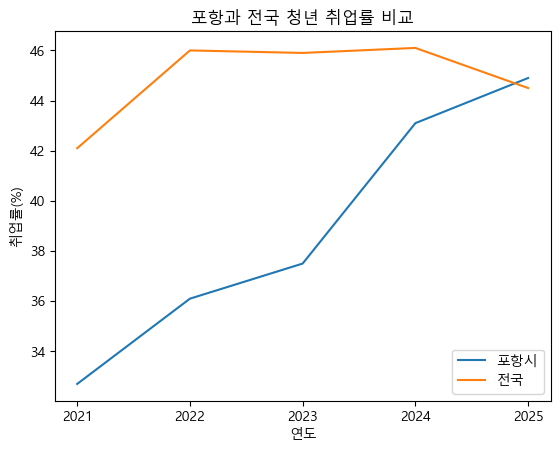

In [7]:
plt.plot(['2021','2022','2023','2024','2025'],goyong.loc['포항시',['2021','2022','2023','2024','2025']],label='포항시')
plt.plot(['2021','2022','2023','2024','2025'],goyong.loc['계',['2021','2022','2023','2024','2025']],label='전국')
plt.title('포항과 전국 청년 취업률 비교')
plt.xlabel('연도')
plt.ylabel('취업률(%)')
plt.legend()
plt.savefig('청년취업률.png')
plt.show()

# 포항시 산업 분포

In [8]:
dff1 = pd.read_csv('시군구_산업별_취업자_11차__20260316144810.csv',header=[0,1])
dff1

,행정구역별,산업별,2025.1/2
,행정구역별,산업별,취업자 (천명)
0,포항시,계,256
1,포항시,"농업, 임업 및 어업 (A)",8
2,포항시,"광·제조업(B,C)",54
3,포항시,건설업 (F),20
4,포항시,"도소매·숙박음식업(G,I)",45
5,포항시,"전기·운수·통신·금융(D,H,J,K)",22
6,포항시,"사업·개인·공공서비스 및 기타(E,L~U)",107


In [9]:
dff1.columns = ['행정구역별','산업별','2025 포항시 종사자(천명)']
dff1

,행정구역별,산업별,2025 포항시 종사자(천명)
0,포항시,계,256
1,포항시,"농업, 임업 및 어업 (A)",8
2,포항시,"광·제조업(B,C)",54
3,포항시,건설업 (F),20
4,포항시,"도소매·숙박음식업(G,I)",45
5,포항시,"전기·운수·통신·금융(D,H,J,K)",22
6,포항시,"사업·개인·공공서비스 및 기타(E,L~U)",107


In [10]:
dff1.drop('행정구역별',axis=1,inplace=True)
dff1

,산업별,2025 포항시 종사자(천명)
0,계,256
1,"농업, 임업 및 어업 (A)",8
2,"광·제조업(B,C)",54
3,건설업 (F),20
4,"도소매·숙박음식업(G,I)",45
5,"전기·운수·통신·금융(D,H,J,K)",22
6,"사업·개인·공공서비스 및 기타(E,L~U)",107


In [11]:
dff1.set_index('산업별',inplace=True)
dff1

,2025 포항시 종사자(천명)
산업별,
계,256
"농업, 임업 및 어업 (A)",8
"광·제조업(B,C)",54
건설업 (F),20
"도소매·숙박음식업(G,I)",45
"전기·운수·통신·금융(D,H,J,K)",22
"사업·개인·공공서비스 및 기타(E,L~U)",107


In [12]:
dff1.drop('계',axis=0,inplace=True)
dff1

,2025 포항시 종사자(천명)
산업별,
"농업, 임업 및 어업 (A)",8
"광·제조업(B,C)",54
건설업 (F),20
"도소매·숙박음식업(G,I)",45
"전기·운수·통신·금융(D,H,J,K)",22
"사업·개인·공공서비스 및 기타(E,L~U)",107


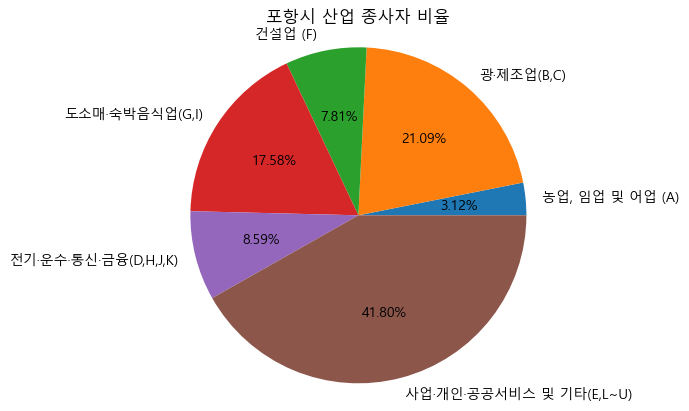

In [13]:
plt.pie(dff1['2025 포항시 종사자(천명)'],labels=dff1.index,autopct='%.2f%%')
plt.title('포항시 산업 종사자 비율')
plt.axis('equal')
plt.savefig('포항 산업 비율.png')
plt.show()

# 청년 산업 종사 비율

In [14]:
dff2 = pd.read_csv('전국_산업_연령_교육정도_종사상지위별_취업자_20260316145116.csv',header=[0,1])
dff2

산업별      2025.1/2           
                                        산업별 취업자 (천명) (천명) 연령(15~29세)
0                                         계         28887       3618
1                        농업, 임업 및 어업(01~03)          1427         23
2                                광 업(05~08)             8          0
3                              제 조 업(10~34)          4397        499
4                전기, 가스, 증기 및 공기 조절 공급업(35)            89          9
5            수도, 하수 및 폐기물 처리, 원료 재생업(36~39)           152         11
6                              건 설 업(41~42)          1948        124
7                           도매 및 소매업(45~47)          3239        440
8                           운수 및 창고업(49~52)          1716        138
9                          숙박 및 음식점업(55~56)          2313        615
10                             정보통신업(58~63)          1151        237
11                          금융 및 보험업(64~66)           810         73
12                                 부동산업(68)           517         16
13                  전문, 과학 및 기술 서비스업(70~73)          1516        251
14          사업시설 관리, 사업 지원 및 임대 서비스업(74~76)          1346        106
15                  공공 행정, 국방 및 사회보장 행정(84)          1369        124
16                              교육 서비스업(85)          1925        297
17                   보건업 및 사회복지 서비스업(86~87)          3180        388
18               예술, 스포츠 및 여가관련 서비스업(90~91)           539        139
19          협회 및 단체, 수리 및 기타 개인 서비스업(94~96)          1153        127
20  가구 내 고용활동 및 달리 분류되지 않은 자가소비 생산활동(97~98)            77          0
21                            국제 및 외국기관(99)            14          1

In [15]:
dff2.columns = ['산업별','2025_취업자(천명)','취업자연령(15~29세)']
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08),8,0
3,제 조 업(10~34),4397,499
4,"전기, 가스, 증기 및 공기 조절 공급업(35)",89,9
5,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",152,11
6,건 설 업(41~42),1948,124
7,도매 및 소매업(45~47),3239,440
8,운수 및 창고업(49~52),1716,138
9,숙박 및 음식점업(55~56),2313,615


In [16]:
dff2.iloc[2] = dff2.iloc[[2,3]].sum()
dff2 = dff2.drop(3).reset_index(drop=True)
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08)제 조 업(10~34),4405,499
3,"전기, 가스, 증기 및 공기 조절 공급업(35)",89,9
4,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",152,11
5,건 설 업(41~42),1948,124
6,도매 및 소매업(45~47),3239,440
7,운수 및 창고업(49~52),1716,138
8,숙박 및 음식점업(55~56),2313,615
9,정보통신업(58~63),1151,237


In [17]:
dff2.iloc[3] = dff2.iloc[[3,7,9,10]].sum()
dff2 = dff2.drop([7,9,10]).reset_index(drop=True)
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08)제 조 업(10~34),4405,499
3,"전기, 가스, 증기 및 공기 조절 공급업(35)운수 및 창고업(49~52)정보통신업...",3766,457
4,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",152,11
5,건 설 업(41~42),1948,124
6,도매 및 소매업(45~47),3239,440
7,숙박 및 음식점업(55~56),2313,615
8,부동산업(68),517,16
9,"전문, 과학 및 기술 서비스업(70~73)",1516,251


In [18]:
dff2.iloc[6] = dff2.iloc[[6,7]].sum()
dff2 = dff2.drop([7]).reset_index(drop=True)
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08)제 조 업(10~34),4405,499
3,"전기, 가스, 증기 및 공기 조절 공급업(35)운수 및 창고업(49~52)정보통신업...",3766,457
4,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",152,11
5,건 설 업(41~42),1948,124
6,도매 및 소매업(45~47)숙박 및 음식점업(55~56),5552,1055
7,부동산업(68),517,16
8,"전문, 과학 및 기술 서비스업(70~73)",1516,251
9,"사업시설 관리, 사업 지원 및 임대 서비스업(74~76)",1346,106


In [19]:
dff2.iloc[4] = dff2.iloc[[4,7,8,9,10,11,12,13,14,15,16]].sum()
dff2 = dff2.drop([7,8,9,10,11,12,13,14,15,16]).reset_index(drop=True)
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08)제 조 업(10~34),4405,499
3,"전기, 가스, 증기 및 공기 조절 공급업(35)운수 및 창고업(49~52)정보통신업...",3766,457
4,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)부동산업(68)전문, 과학 및...",11788,1460
5,건 설 업(41~42),1948,124
6,도매 및 소매업(45~47)숙박 및 음식점업(55~56),5552,1055


In [20]:
dff2.loc[1,'산업별'] = '농업, 임업 및 어업 (A)'
dff2.loc[2,'산업별'] = '광·제조업(B,C)'
dff2.loc[3,'산업별'] = '전기·운수·통신·금융(D,H,J,K)'
dff2.loc[4,'산업별'] = '사업·개인·공공서비스 및 기타(E,L~U)'
dff2.loc[5,'산업별'] = '건설업 (F)'
dff2.loc[6,'산업별'] = '도소매·숙박음식업(G,I)'
dff2 = dff2.drop([0]).reset_index(drop=True)
dff2

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,"농업, 임업 및 어업 (A)",1427,23
1,"광·제조업(B,C)",4405,499
2,"전기·운수·통신·금융(D,H,J,K)",3766,457
3,"사업·개인·공공서비스 및 기타(E,L~U)",11788,1460
4,건설업 (F),1948,124
5,"도소매·숙박음식업(G,I)",5552,1055


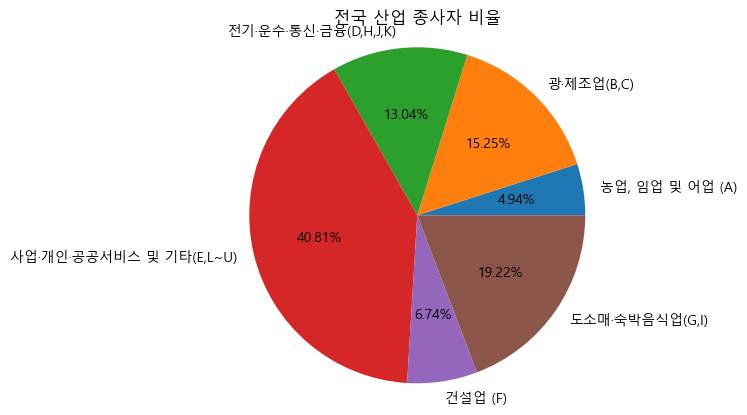

In [21]:
plt.pie(dff2['2025_취업자(천명)'],labels=dff2['산업별'],autopct='%.2f%%')
plt.title('전국 산업 종사자 비율')
plt.axis('equal')
plt.savefig('전국 산업 비율.png')
plt.show()

In [22]:
dff3 = pd.read_csv('전국_산업_연령_교육정도_종사상지위별_취업자_20260316145116.csv',header=[0,1])
dff3.columns = ['산업별','2025_취업자(천명)','취업자연령(15~29세)']
dff3

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,광 업(05~08),8,0
3,제 조 업(10~34),4397,499
4,"전기, 가스, 증기 및 공기 조절 공급업(35)",89,9
5,"수도, 하수 및 폐기물 처리, 원료 재생업(36~39)",152,11
6,건 설 업(41~42),1948,124
7,도매 및 소매업(45~47),3239,440
8,운수 및 창고업(49~52),1716,138
9,숙박 및 음식점업(55~56),2313,615


In [23]:
dff3 = dff3.drop([2,4,5,12,13,14,15,18,19,20,21]).reset_index(drop=True)
dff3

,산업별,2025_취업자(천명),취업자연령(15~29세)
0,계,28887,3618
1,"농업, 임업 및 어업(01~03)",1427,23
2,제 조 업(10~34),4397,499
3,건 설 업(41~42),1948,124
4,도매 및 소매업(45~47),3239,440
5,운수 및 창고업(49~52),1716,138
6,숙박 및 음식점업(55~56),2313,615
7,정보통신업(58~63),1151,237
8,금융 및 보험업(64~66),810,73
9,교육 서비스업(85),1925,297


In [25]:
dff3["15~29세 비율(%)"] = (dff3["취업자연령(15~29세)"] / dff3["2025_취업자(천명)"] * 100).round(2)
dff3

,산업별,2025_취업자(천명),취업자연령(15~29세),15~29세 비율(%)
0,계,28887,3618,12.52
1,"농업, 임업 및 어업(01~03)",1427,23,1.61
2,제 조 업(10~34),4397,499,11.35
3,건 설 업(41~42),1948,124,6.37
4,도매 및 소매업(45~47),3239,440,13.58
5,운수 및 창고업(49~52),1716,138,8.04
6,숙박 및 음식점업(55~56),2313,615,26.59
7,정보통신업(58~63),1151,237,20.59
8,금융 및 보험업(64~66),810,73,9.01
9,교육 서비스업(85),1925,297,15.43
